<a href="https://colab.research.google.com/github/izhanys/PBA_Bima_5026231060/blob/main/Tugas/Week%202/Week_2_1_Scrapping_Bima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Scrapping Google Apps Review-Bima+**

In [ ]:
pip install google_play_scraper textblob seaborn -q

In [ ]:
from google_play_scraper import Sort, reviews
import pandas as pd
import csv

# 1. Proses Scraping
result, _ = reviews(
    'com.linkit.bimatri',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=75000
)

# 2. Masukkan ke DataFrame
df = pd.DataFrame(result)

# 3. Simpan ke CSV dengan pengaturan khusus
df.to_csv(
    'review_bima_75000.csv',
    sep=',',
    index=False,
    encoding='utf-8-sig',
    quoting=csv.QUOTE_ALL
)

print("File 'review_bima_75000.csv' berhasil dibuat.")

File 'review_bima_75000.csv' berhasil dibuat.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              75000 non-null  object        
 1   userName              75000 non-null  object        
 2   userImage             75000 non-null  object        
 3   content               75000 non-null  object        
 4   score                 75000 non-null  int64         
 5   thumbsUpCount         75000 non-null  int64         
 6   reviewCreatedVersion  63735 non-null  object        
 7   at                    75000 non-null  datetime64[ns]
 8   replyContent          74990 non-null  object        
 9   repliedAt             74990 non-null  datetime64[ns]
 10  appVersion            63735 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 6.3+ MB


In [ ]:
df_analysis = df.loc[:, ['content', 'score', 'thumbsUpCount',
                         'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt']]
df_analysis

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,"saat ini lumnyan bagus jringnnya,semoga kedepa...",4,0,5.13.0,2026-03-30 17:09:23,"Hai Kak Nova, terima kasih atas apresiasi yang...",2026-03-31 12:12:26
1,good👍,5,0,None,2026-03-30 16:48:10,"Hi Ms. Tasya, thank you for your appreciation ...",2026-03-31 12:05:15
2,jaringan busuk bangat anjinggg asal maen ML do...,1,0,5.13.0,2026-03-30 16:31:28,"Hi Kak Riyan, mohon maaf ya. Kami sarankan res...",2026-03-30 18:42:01
3,ok,5,0,5.13.0,2026-03-30 16:24:40,"Hai Kak Elasiti, terima kasih atas apresiasi y...",2026-03-31 12:03:38
4,LAG TROSSSS,1,0,None,2026-03-30 16:00:43,"Hai Kak, mohon maaf ya. Perihal kendala yang k...",2026-03-31 11:16:52
...,...,...,...,...,...,...,...
74995,"Kenapa gabisa lihat isi pulsa, internet",5,0,5.5.0,2024-12-23 02:34:42,"Hai Kak Miswan, maaf ya. Bisa coba re-login ap...",2024-12-24 12:02:22
74996,Puas,5,0,5.5.0,2024-12-23 02:28:27,"Hi Kak Achmad, Terima kasih atas apresiasi yan...",2024-12-24 06:10:25
74997,Tolong saya beli kuota harga 50k gk bisa di gu...,1,0,5.5.0,2024-12-23 02:28:14,"Hai Kak Valentino, maaf ya. Saran kami bisa co...",2024-12-24 11:59:47
74998,tidak bisa buka bima,5,0,5.5.0,2024-12-23 02:26:31,"Hai Kak Desi, maaf yah. Pastikan jaringan stab...",2024-12-24 10:51:08


In [ ]:
df['score'].value_counts()

,count
score,
5,34554
1,25309
4,5763
3,4906
2,4468


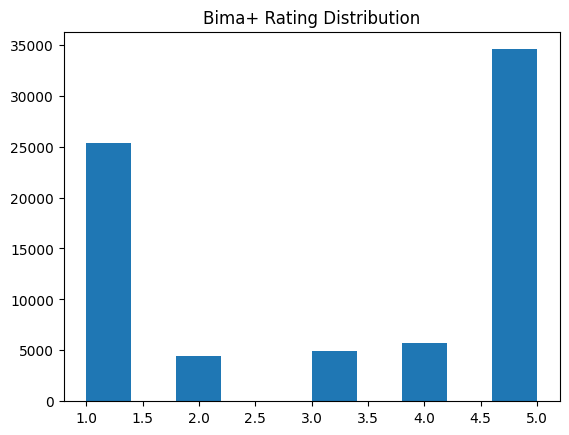

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['score'])
plt.title('Bima+ Rating Distribution')
plt.show()

In [ ]:
!pip install emoji wordcloud -q

import emoji
import nltk
from nltk import word_tokenize
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

In [ ]:
from textblob import TextBlob

# sentiment polarity using TextBlob
df['sentiment_polarity'] = df['content'].astype(str).apply(lambda x: TextBlob(x).polarity)
df['sentiment_subjective'] = df['content'].astype(str).apply(lambda x: TextBlob(x).subjectivity)
df.loc[:, ['content', 'score', 'sentiment_polarity', 'sentiment_subjective']]

,content,score,sentiment_polarity,sentiment_subjective
0,"saat ini lumnyan bagus jringnnya,semoga kedepa...",4,0.0,0.0
1,good👍,5,0.0,0.0
2,jaringan busuk bangat anjinggg asal maen ml do...,1,0.0,0.0
3,ok,5,0.5,0.5
4,lag trossss,1,0.0,0.0
...,...,...,...,...
74995,"kenapa gabisa lihat isi pulsa, internet",5,0.0,0.0
74996,puas,5,0.0,0.0
74997,tolong saya beli kuota harga 50k gk bisa di gu...,1,0.0,0.0
74998,tidak bisa buka bima,5,0.0,0.0


Lowercasing

In [ ]:
df['content'] = df['content'].astype(str)
print('Before:')
print(df['content'][0])
print(df['content'][1])
print(df['content'][2])

Before:
saat ini lumnyan bagus jringnnya,semoga kedepan pket nya pun lebih murah" lgi
good👍
jaringan busuk bangat anjinggg asal maen ML doang ngelek mlu gua heran monyet nyesel bgt gua mna baru beli 30gb cuma buat ngelek doang !!!


In [ ]:
df['content'] = df['content'].apply(lambda x: x.lower())
print('After lowercasing:')
print(df['content'][0])
print(df['content'][1])
print(df['content'][2])

After lowercasing:
saat ini lumnyan bagus jringnnya,semoga kedepan pket nya pun lebih murah" lgi
good👍
jaringan busuk bangat anjinggg asal maen ml doang ngelek mlu gua heran monyet nyesel bgt gua mna baru beli 30gb cuma buat ngelek doang !!!


Stopwords Removal(Indonesian)

In [ ]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)
indonesian_stopwords = stopwords.words('indonesian')
print(indonesian_stopwords[:20])

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


In [ ]:
import string
df['wordCount'] = [len(review.split()) for review in df['content']]
df['uppercaseCharCount'] = [sum(c.isupper() for c in review) for review in df['content']]
df['specialCharCount'] = [sum(c in string.punctuation for c in review) for review in df['content']]

df.loc[:, ['content', 'score', 'sentiment_polarity', 'sentiment_subjective',
           'wordCount', 'uppercaseCharCount', 'specialCharCount']]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,"saat ini lumnyan bagus jringnnya,semoga kedepa...",4,0.0,0.0,12,0,2
1,good👍,5,0.0,0.0,1,0,0
2,jaringan busuk bangat anjinggg asal maen ml do...,1,0.0,0.0,25,0,3
3,ok,5,0.5,0.5,1,0,0
4,lag trossss,1,0.0,0.0,2,0,0
...,...,...,...,...,...,...,...
74995,"kenapa gabisa lihat isi pulsa, internet",5,0.0,0.0,6,0,1
74996,puas,5,0.0,0.0,1,0,0
74997,tolong saya beli kuota harga 50k gk bisa di gu...,1,0.0,0.0,10,0,2
74998,tidak bisa buka bima,5,0.0,0.0,4,0,0


In [ ]:
df['sentiment_rating'] = df['score'].apply(
    lambda x: 'Positive' if x > 3 else ('Neutral' if x == 3 else 'Negative')
)
df.loc[:, ['content', 'score', 'sentiment_polarity', 'sentiment_subjective', 'sentiment_rating']]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,"saat ini lumnyan bagus jringnnya,semoga kedepa...",4,0.0,0.0,Positive
1,good👍,5,0.0,0.0,Positive
2,jaringan busuk bangat anjinggg asal maen ml do...,1,0.0,0.0,Negative
3,ok,5,0.5,0.5,Positive
4,lag trossss,1,0.0,0.0,Negative
...,...,...,...,...,...
74995,"kenapa gabisa lihat isi pulsa, internet",5,0.0,0.0,Positive
74996,puas,5,0.0,0.0,Positive
74997,tolong saya beli kuota harga 50k gk bisa di gu...,1,0.0,0.0,Negative
74998,tidak bisa buka bima,5,0.0,0.0,Positive


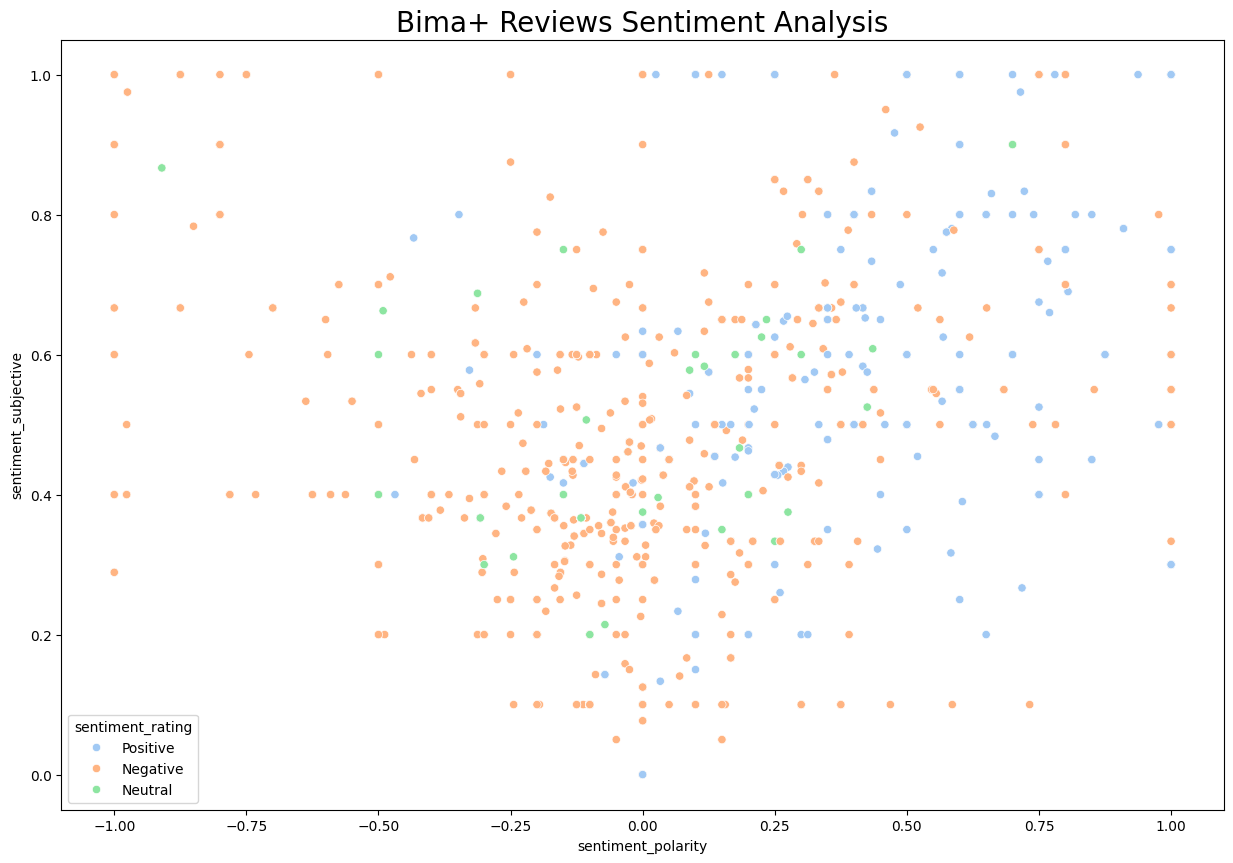

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
sns.scatterplot(x=df['sentiment_polarity'], y=df['sentiment_subjective'],
                hue=df['sentiment_rating'], edgecolor='white', palette='pastel')
plt.title('Bima+ Reviews Sentiment Analysis', fontsize=20)
plt.show()

In [ ]:
def freq_words(x, terms=30):
    all_words = ' '.join([text for text in x]).split()
    fdist = FreqDist(all_words)
    words_df = pd.DataFrame({'word': list(fdist.keys()), 'count': list(fdist.values())})
    d = words_df.nlargest(columns='count', n=terms)
    plt.figure(figsize=(20, 5))
    sns.barplot(data=d, x='word', y='count', palette='viridis')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Top {terms} Most Frequent Words')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_31907/85699166.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=d, x='word', y='count', palette='viridis')


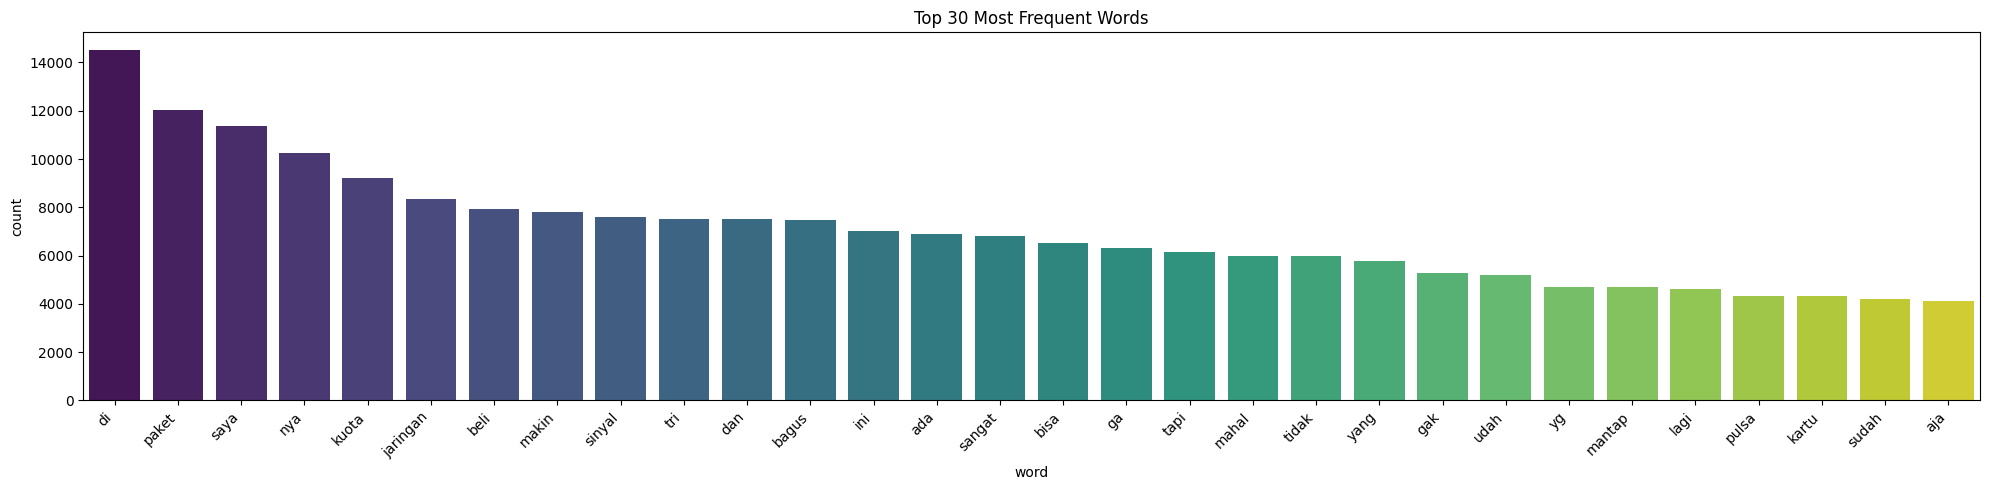

In [ ]:
from nltk.probability import FreqDist
freq_words(df['content'])

In [ ]:
!pip install Sastrawi -q
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()
df['content'] = df['content'].apply(lambda x: stopword_remover.remove(x))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.2 MB/s eta 0:00:00


In [ ]:
# also remove English stopwords
english_stopwords = stopwords.words('english')
df['content'] = df['content'].apply(
    lambda x: ' '.join([w for w in x.split() if w not in english_stopwords])
)

In [ ]:
df.loc[:, ['content', 'score', 'sentiment_polarity', 'sentiment_subjective', 'sentiment_rating']]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,"ini lumnyan bagus jringnnya,semoga kedepan pke...",4,0.0,0.0,Positive
1,good👍,5,0.0,0.0,Positive
2,jaringan busuk bangat anjinggg asal maen ml do...,1,0.0,0.0,Negative
3,,5,0.5,0.5,Positive
4,lag trossss,1,0.0,0.0,Negative
...,...,...,...,...,...
74995,"gabisa lihat isi pulsa, internet",5,0.0,0.0,Positive
74996,puas,5,0.0,0.0,Positive
74997,saya beli kuota harga 50k gk di gunakan!!,1,0.0,0.0,Negative
74998,bisa buka bima,5,0.0,0.0,Positive


/tmp/ipykernel_31907/85699166.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=d, x='word', y='count', palette='viridis')


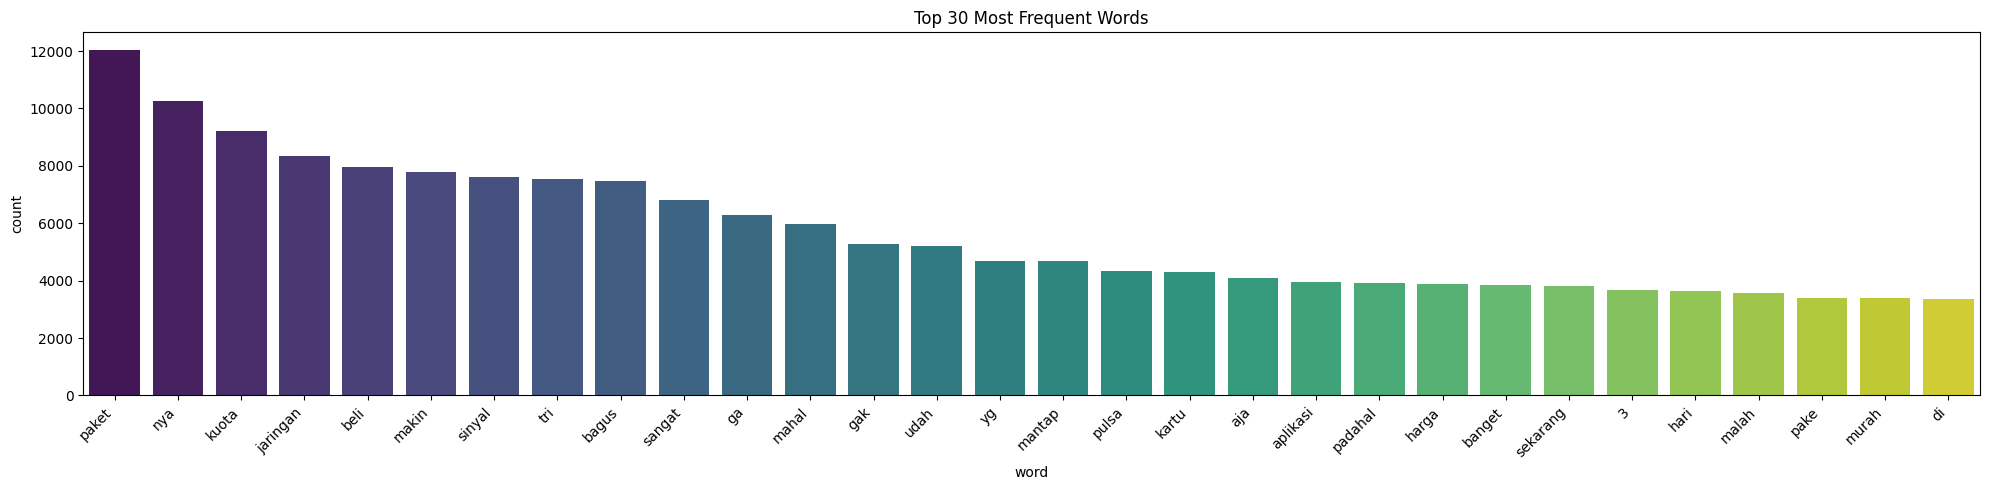

In [ ]:
freq_words(df['content'])